In [1]:
# imports
import mne
import matplotlib.pyplot as plt

In [2]:
# load eeg
file_path = "../data/raw/S001R04.edf"

raw = mne.io.read_raw_edf(
    file_path,
    preload=True
)

Extracting EDF parameters from ../data/raw/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


In [3]:
# copy
raw_preprocessed = raw.copy()

In [4]:
# channel type
print(raw_preprocessed.get_channel_types())

['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']


In [5]:
# summery
from collections import Counter

print(Counter(raw_preprocessed.get_channel_types()))

Counter({'eeg': 64})


In [6]:
# montage
raw_preprocessed.rename_channels(
    lambda name: name.rstrip(".")
)

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [7]:
print(raw_preprocessed.ch_names)

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']


In [8]:
# standard montage
montage = mne.channels.make_standard_montage("standard_1020")

In [9]:
raw_preprocessed.set_montage(
    montage,
    on_missing="warn"
)

C:\Users\SarayeTell\AppData\Local\Temp\ipykernel_17252\965009683.py:1: RuntimeWarning: DigMontage is only a subset of info. There are 28 channel positions not present in the DigMontage. The channels missing from the montage are:

['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'Ft7', 'Ft8', 'Tp7', 'Tp8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.
  raw_preprocessed.set_montage(


<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

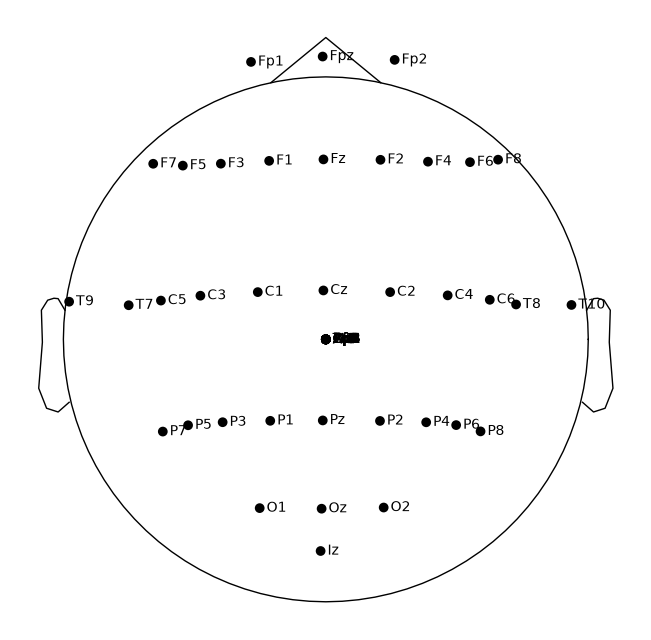

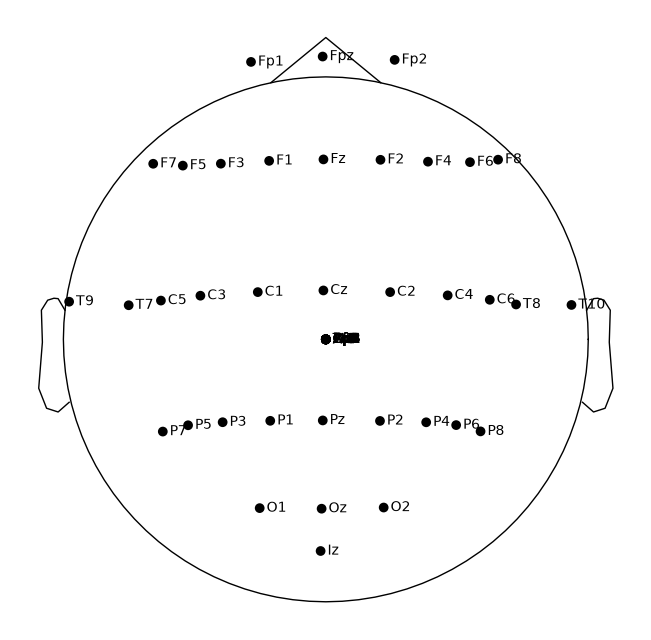

In [10]:
raw_preprocessed.plot_sensors(
    show_names=True
)

In [11]:
print(raw_preprocessed.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 64 channels>


In [12]:
print(raw_preprocessed.info["dig"])

[<DigPoint |        LPA : (-82.5, -0.0, 0.0) mm     : head frame>, <DigPoint |     Nasion : (0.0, 114.0, 0.0) mm      : head frame>, <DigPoint |        RPA : (82.5, 0.0, -0.0) mm      : head frame>, <DigPoint |     EEG #1 : (-30.9, 114.6, 27.9) mm   : head frame>, <DigPoint |     EEG #2 : (-1.3, 119.1, 32.9) mm    : head frame>, <DigPoint |     EEG #3 : (28.4, 115.3, 27.7) mm    : head frame>, <DigPoint |    EEG #16 : (-71.9, 73.1, 25.8) mm    : head frame>, <DigPoint |    EEG #17 : (-66.1, 80.2, 53.8) mm    : head frame>, <DigPoint |    EEG #18 : (-51.8, 86.7, 78.7) mm    : head frame>, <DigPoint |    EEG #19 : (-29.0, 91.4, 96.6) mm    : head frame>, <DigPoint |    EEG #20 : (-1.2, 93.3, 102.6) mm    : head frame>, <DigPoint |    EEG #21 : (28.0, 91.9, 95.8) mm     : head frame>, <DigPoint |    EEG #22 : (50.3, 87.4, 77.3) mm     : head frame>, <DigPoint |    EEG #23 : (66.3, 81.5, 53.1) mm     : head frame>, <DigPoint |    EEG #24 : (71.4, 74.5, 25.1) mm     : head frame>, <DigPoint

In [13]:
print(raw_preprocessed.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 64 channels>


In [14]:
raw_preprocessed = raw.copy()

In [15]:
def standardize_channel_name(name):
    replacements = {
        "Fc": "FC",
        "Cp": "CP",
        "Af": "AF",
        "Ft": "FT",
        "Tp": "TP",
        "Po": "PO",
    }

    for old, new in replacements.items():
        if name.startswith(old):
            return new + name[len(old):]

    return name

In [16]:
raw_preprocessed.rename_channels(
    standardize_channel_name
)

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [17]:
print(raw_preprocessed.ch_names)

['FC5.', 'FC3.', 'FC1.', 'FCz.', 'FC2.', 'FC4.', 'FC6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'CP5.', 'CP3.', 'CP1.', 'CPz.', 'CP2.', 'CP4.', 'CP6.', 'Fp1.', 'Fpz.', 'Fp2.', 'AF7.', 'AF3.', 'AFz.', 'AF4.', 'AF8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'FT7.', 'FT8.', 'T7..', 'T8..', 'T9..', 'T10.', 'TP7.', 'TP8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'PO7.', 'PO3.', 'POz.', 'PO4.', 'PO8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [18]:
montage = mne.channels.make_standard_montage(
    "standard_1020"
)

In [19]:
raw_preprocessed.set_montage(
    montage,
    on_missing="warn"
)

C:\Users\SarayeTell\AppData\Local\Temp\ipykernel_17252\965009683.py:1: RuntimeWarning: DigMontage is only a subset of info. There are 64 channel positions not present in the DigMontage. The channels missing from the montage are:

['FC5.', 'FC3.', 'FC1.', 'FCz.', 'FC2.', 'FC4.', 'FC6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'CP5.', 'CP3.', 'CP1.', 'CPz.', 'CP2.', 'CP4.', 'CP6.', 'Fp1.', 'Fpz.', 'Fp2.', 'AF7.', 'AF3.', 'AFz.', 'AF4.', 'AF8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'FT7.', 'FT8.', 'T7..', 'T8..', 'T9..', 'T10.', 'TP7.', 'TP8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'PO7.', 'PO3.', 'POz.', 'PO4.', 'PO8.', 'O1..', 'Oz..', 'O2..', 'Iz..'].

Consider using inst.rename_channels to match the montage nomenclature, or inst.set_channel_types if these are not EEG channels, or use the on_missing parameter if the channel positions are allowed to be unknown in your analyses.
  raw_preprocessed.set_mon

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [20]:
montage_channels = set(montage.ch_names)

missing_channels = [
    ch for ch in raw_preprocessed.ch_names
    if ch not in montage_channels
]

print("Number of missing channels:", len(missing_channels))
print("Missing channels:", missing_channels)

Number of missing channels: 64
Missing channels: ['FC5.', 'FC3.', 'FC1.', 'FCz.', 'FC2.', 'FC4.', 'FC6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'CP5.', 'CP3.', 'CP1.', 'CPz.', 'CP2.', 'CP4.', 'CP6.', 'Fp1.', 'Fpz.', 'Fp2.', 'AF7.', 'AF3.', 'AFz.', 'AF4.', 'AF8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'FT7.', 'FT8.', 'T7..', 'T8..', 'T9..', 'T10.', 'TP7.', 'TP8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'PO7.', 'PO3.', 'POz.', 'PO4.', 'PO8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


In [28]:
def standardize_channel_name(name):
   
    replacements = {
        "Fc": "FC",
        "Cp": "CP",
        "Af": "AF",
        "Ft": "FT",
        "Tp": "TP",
        "Po": "PO",
    }
    for old, new in replacements.items():
        if name.startswith(old):
            name = new + name[len(old):]
            break


    name = name.rstrip('.') 
    
    
    name = name.replace('..', '.').rstrip('.')
    
    return name


raw_preprocessed.rename_channels(standardize_channel_name)


print(raw_preprocessed.ch_names[:10])

['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1']


In [26]:
montage = mne.channels.make_standard_montage("standard_1020")
raw_preprocessed.set_montage(montage, on_missing="warn")

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

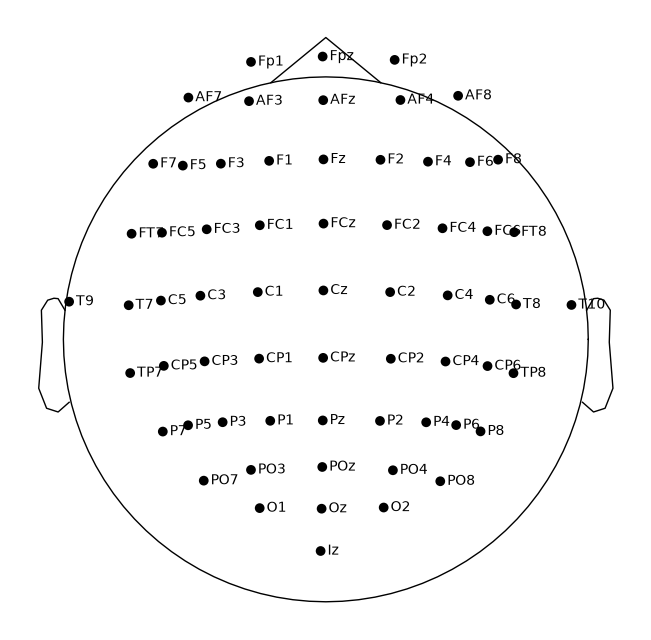

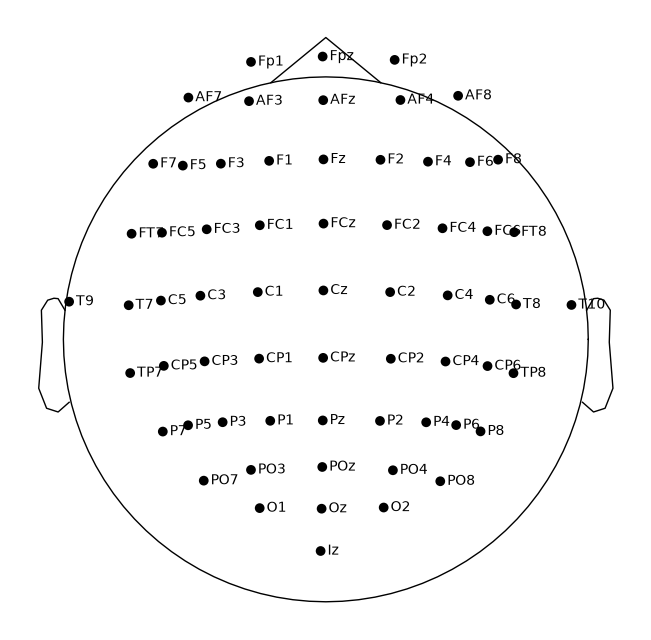

In [32]:
raw_preprocessed.plot_sensors(
    show_names=True
)

In [31]:
print(raw_preprocessed.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 64 channels>


In [33]:
print("Current EEG reference information:")
print(raw_preprocessed.info["custom_ref_applied"])

Current EEG reference information:
0 (FIFFV_MNE_CUSTOM_REF_OFF)


In [34]:
print("Number of EEG channels:",
      len(mne.pick_types(
          raw_preprocessed.info,
          eeg=True
      )))

Number of EEG channels: 64


In [35]:
raw_avg_ref = raw_preprocessed.copy()

raw_avg_ref.set_eeg_reference(
    ref_channels="average"
)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [37]:
print(raw_avg_ref)

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>


In [38]:
print(raw_avg_ref.info["custom_ref_applied"])

1 (FIFFV_MNE_CUSTOM_REF_ON)


In [39]:
raw_filtered = raw_avg_ref.copy()

In [40]:
raw_filtered.filter(
    l_freq=8.0,
    h_freq=30.0
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

Using matplotlib as 2D backend.


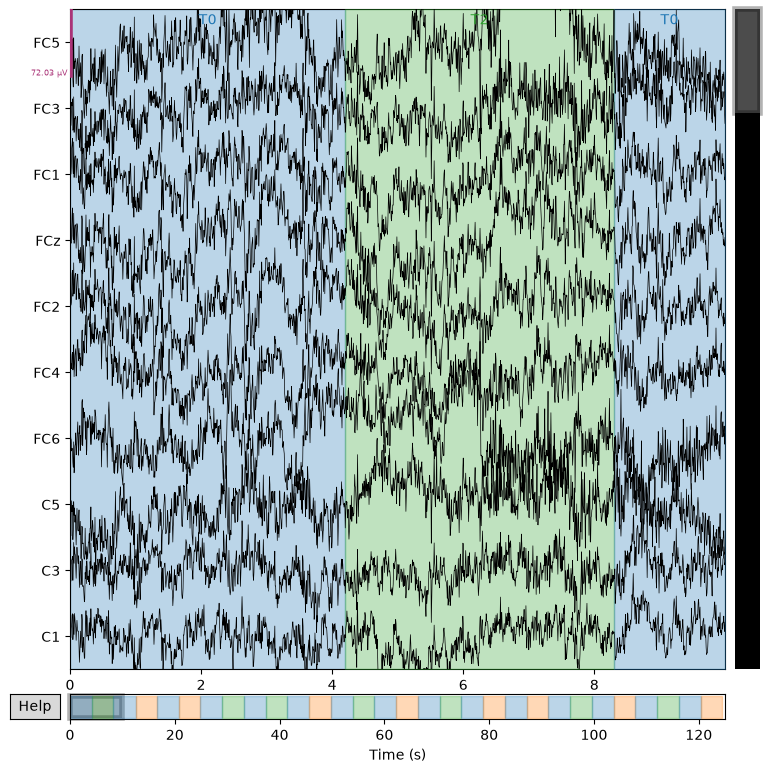

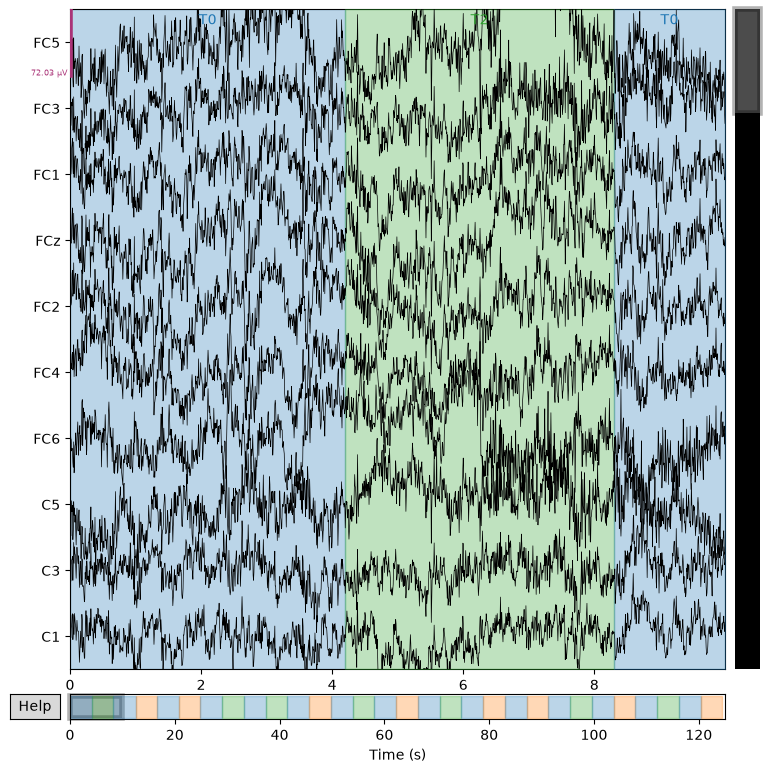

In [41]:
raw_avg_ref.plot(
    n_channels=10,
    duration=10,
    scalings="auto"
)

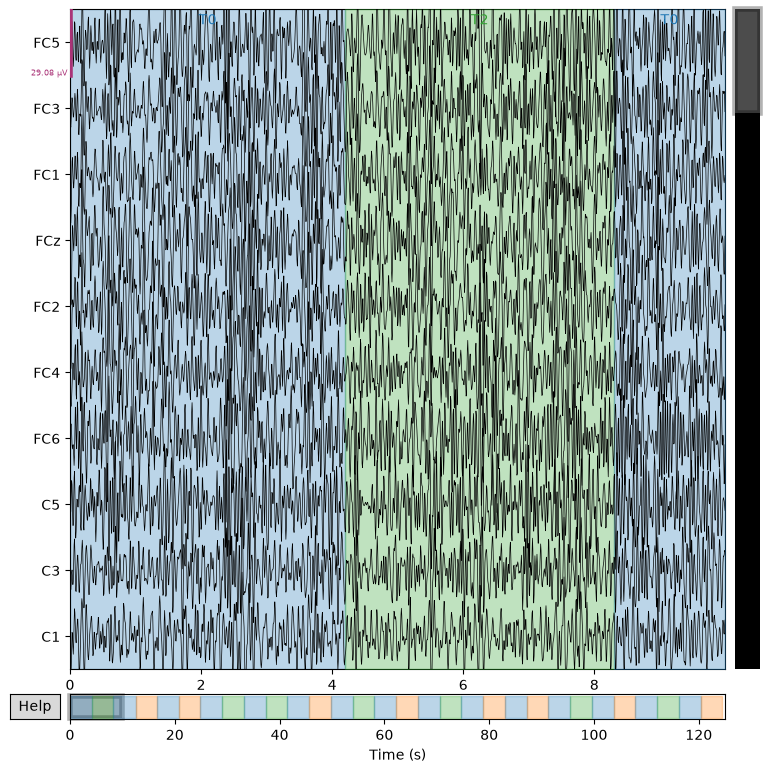

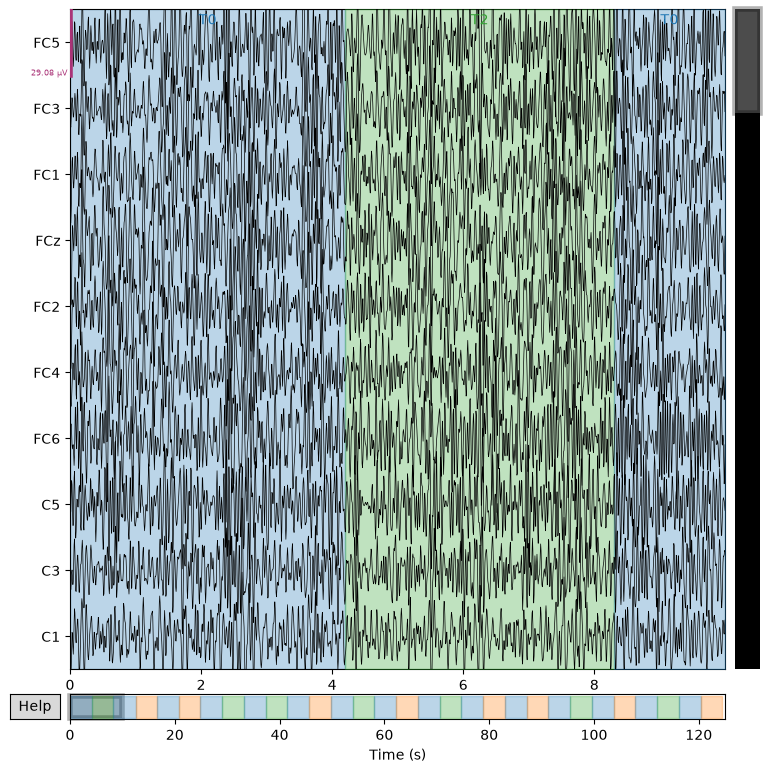

In [42]:
raw_filtered.plot(
    n_channels=10,
    duration=10,
    scalings="auto"
)

In [ ]:
events, event_id = mne.events_from_annotations(raw_filtered)

print(event_id)  

event_id_mi = {
    "Left": event_id["T1"],
    "Right": event_id["T2"]
}

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [45]:
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id=event_id_mi,
    tmin=1.0,
    tmax=4.0,
    baseline=None,
    preload=True
)

Not setting metadata
15 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 15 events and 481 original time points ...
0 bad epochs dropped


In [46]:
print(epochs)

<Epochs | 15 events (all good), 1 – 4 s (baseline off), ~3.6 MiB, data loaded,
 'Left': 8
 'Right': 7>


In [47]:
print("Number of epochs:", len(epochs))

Number of epochs: 15


In [48]:
print("Epochs shape:")
print(epochs.get_data().shape)

Epochs shape:
(15, 64, 481)


In [49]:
print(
    "Left trials:",
    len(epochs["Left"])
)

print(
    "Right trials:",
    len(epochs["Right"])
)

Left trials: 8
Right trials: 7
